# Model Predictions (qubit-TransmonCross-Hamiltonian_params)
## Hamiltonian --> Qiskit Metal

Inverse model with surrogate-defined loss

## Configuration

In [1]:
# The parameter file is where the hyperparameters are set. 
# It's reccomended to look at that file first, its interesting and you can set stuff there

from parameters_surrogate_defined_loss import *

## Library

In [2]:
import os, gc, math
from pathlib import Path
import numpy as np
import pandas as pd
from pandas import json_normalize
import joblib
import matplotlib.pyplot as plt

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense

## Dataset

### Load

In [3]:
# Load the data saved from ml_00 notebook

# inputs are the Hamiltonian values (what we want to invert)
X_train = np.load(f'{DATA_DIR}/npy/x_train_one_hot_encoding_augmented.npy', allow_pickle=True)
X_val   = np.load(f'{DATA_DIR}/npy/x_val_one_hot_encoding_augmented.npy', allow_pickle=True)
X_test  = np.load(f'{DATA_DIR}/npy/x_test_one_hot_encoding_augmented.npy', allow_pickle=True)

# Qiskit Metal params (all continuous for transmon cross)
y_train = np.load(f'{DATA_DIR}/npy/y_train_one_hot_encoding_augmented.npy', allow_pickle=True)
y_val   = np.load(f'{DATA_DIR}/npy/y_val_one_hot_encoding_augmented.npy', allow_pickle=True)
y_test  = np.load(f'{DATA_DIR}/npy/y_test_one_hot_encoding_augmented.npy', allow_pickle=True)

# column names
with open('X_names', 'r') as f:
    Hamiltonian_column_names = f.read().splitlines()

qiskit_param_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

print(f'Inputs (Hamiltonian):     {X_train.shape[1]} columns')
print(f'Outputs (Qiskit params):  {y_train.shape[1]} columns')
print(f'\nHamiltonian columns:  {Hamiltonian_column_names}')
print(f'Qiskit param columns: {qiskit_param_names}')

Inputs (Hamiltonian):     2 columns
Outputs (Qiskit params):  3 columns

Hamiltonian columns:  ['qubit_frequency_GHz', 'anharmonicity_MHz']
Qiskit param columns: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']


### Define conversion layer

In [4]:
# Must define this class before loading the saved combined model
class ScalerConversionLayer(tf.keras.layers.Layer):
    def __init__(self, scale_a, scale_b, **kwargs):
        kwargs.setdefault('trainable', False)
        super().__init__(**kwargs)
        self._scale_a = tf.constant(scale_a, dtype=tf.float32)
        self._scale_b = tf.constant(scale_b, dtype=tf.float32)
        self._cfg = dict(
            scale_a=list(scale_a) if hasattr(scale_a, '__iter__') else scale_a,
            scale_b=list(scale_b) if hasattr(scale_b, '__iter__') else scale_b)

    def call(self, inputs):
        a = tf.cast(self._scale_a, inputs.dtype)
        b = tf.cast(self._scale_b, inputs.dtype)
        return inputs * a + b

    def get_config(self):
        config = super().get_config()
        config.update(self._cfg)
        return config

### Visualize model

In [5]:
# Decide which model file to use
encoding = 'surrogate_defined_loss'
chosen_path = f'model/best_keras_model_{encoding}.keras'
X_test_cur = np.asarray(X_test)
y_test_cur = np.asarray(y_test)

# Load output headers (Hamiltonian column names — the reconstruction target)
headers = Hamiltonian_column_names
print(f'Model path: {chosen_path}')
print(f'Hamiltonian output headers: {headers}')

Model path: model/best_keras_model_surrogate_defined_loss.keras
Hamiltonian output headers: ['qubit_frequency_GHz', 'anharmonicity_MHz']


In [6]:
#look at the best model, ooh so pretty
tf.keras.backend.clear_session()
gc.collect()
try:
    tf.config.experimental.reset_memory_stats('GPU:0')
except Exception:
    pass

with tf.device('/CPU:0'):
    combined_model = load_model(chosen_path, compile=False,
        custom_objects={'ScalerConversionLayer': ScalerConversionLayer})
    inverse_model = combined_model.get_layer('inverse_model')
    
    # get both the reconstructed Hamiltonian and the predicted Qiskit params
    predictions = combined_model.predict(X_test_cur, verbose=0)
    if isinstance(predictions, list):
        Hamiltonian_pred = predictions[0]
        qiskit_pred = predictions[1]
    else:
        Hamiltonian_pred = predictions
        qiskit_pred = inverse_model.predict(X_test_cur, verbose=0)

print(f'\n—— {os.path.basename(chosen_path)} ——')
print('\nCombined model (inverse + conversion + frozen surrogate):')
combined_model.summary()
print('\nInverse model only:')
inverse_model.summary()
print(f'\nSamples: {len(X_test_cur)} | Hamiltonian targets dim: {X_test_cur.shape[1]} | Qiskit dim: {y_test_cur.shape[1]}')

I0000 00:00:1774889214.329944    2930 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18292 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 2g.20gb, pci bus id: 0000:00:11.0, compute capability: 8.0



—— best_keras_model_surrogate_defined_loss.keras ——

Combined model (inverse + conversion + frozen surrogate):


I0000 00:00:1774889214.568776    3662 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Model: "combined_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ combined_input (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inverse_model (Sequential)      │ (None, 3)              │           387 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scaler_conversion               │ (None, 3)              │             0 │
│ (ScalerConversionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 2)              │         4,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qiskit_output (Dense)           │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)


Samples: 291 | Hamiltonian targets dim: 2 | Qiskit dim: 3


In [7]:
# look at some more specific model params
inv = combined_model.get_layer('inverse_model')

neurons_per_layer = [
    l.units for l in inv.layers
    if isinstance(l, Dense) and l.name.startswith('fc')
]
print('Best NEURONS_PER_LAYER:', neurons_per_layer)

dropouts = [
    (l.name, float(l.rate)) for l in inv.layers
    if isinstance(l, tf.keras.layers.Dropout)
]
if dropouts:
    print('Best DROPOUT rate(s):', dropouts)
else:
    print('Best DROPOUT rate(s): none found')

Best NEURONS_PER_LAYER: [64]
Best DROPOUT rate(s): [('dropout0', 0.0)]


# Scaled

In [8]:
N_SAMPLES_TO_SHOW = 3 # change this to print more stuff

X_test_cur = np.asarray(X_test_cur)
y_test_cur = np.asarray(y_test_cur)
Hamiltonian_pred   = np.asarray(Hamiltonian_pred)
qiskit_pred = np.asarray(qiskit_pred)

N, P = X_test_cur.shape  # P = number of Hamiltonian columns

# scaled errors on Hamiltonian reconstruction
Hamiltonian_abs_errors = np.abs(X_test_cur - Hamiltonian_pred)
Hamiltonian_sq_errors  = (X_test_cur - Hamiltonian_pred) ** 2

# building dataframe for Hamiltonian reconstruction
rows = []
for i in range(N_SAMPLES_TO_SHOW):
    for j in range(P):
        label = headers[j] if j < len(headers) else f'Hamiltonian_col_{j}'
        rows.append({
            'sample_idx': i,
            'param': label,
            'ref':  X_test_cur[i, j],
            'pred': Hamiltonian_pred[i, j],
            'abs_error': Hamiltonian_abs_errors[i, j],
            'sq_error':  Hamiltonian_sq_errors[i, j],
        })

df = pd.DataFrame(rows)

# save scaled predictions
out_csv = Path(f'surrogate_loss_Hamiltonian_reconstruction_scaled_{encoding}.csv')
df.to_csv(out_csv, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv.resolve()}\n')

# Pretty print per-sample
for i in range(N_SAMPLES_TO_SHOW):
    # Hamiltonian reconstruction table
    sub = df[df['sample_idx'] == i].copy()
    sub = sub[['param', 'ref', 'pred', 'abs_error', 'sq_error']]
    print(f'— Sample {i} — Hamiltonian reconstruction (scaled)')
    print(sub.to_string(index=False))
    
    # predicted Qiskit params that produced this Hamiltonian
    print(f'\n  Predicted Qiskit Metal params (scaled):')
    for j, col_name in enumerate(qiskit_param_names):
        short_name = col_name.replace('design_options.', '')
        pred_val = qiskit_pred[i, j]
        ref_val  = y_test_cur[i, j]
        print(f'    {short_name:40s}  pred={pred_val}  ref={ref_val}  err={abs(pred_val - ref_val)}')
    print()

print('Global scaled Hamiltonian reconstruction error stats:')
print('  min abs_error:', float(Hamiltonian_abs_errors.min()))
print('  median abs_error:', float(np.median(Hamiltonian_abs_errors)))
print('  max abs_error:', float(Hamiltonian_abs_errors.max()))

Saved CSV -> /home/abouzahr/Hamiltonian_branch/ML_qubit_design/model_predict_qubit_TransmonCross_cap_matrix/surrogate_loss_Hamiltonian_reconstruction_scaled_surrogate_defined_loss.csv

— Sample 0 — Hamiltonian reconstruction (scaled)
              param      ref     pred  abs_error     sq_error
qubit_frequency_GHz 0.229409 0.229111   0.000299 8.935553e-08
  anharmonicity_MHz 0.858338 0.856911   0.001427 2.035899e-06

  Predicted Qiskit Metal params (scaled):
    connection_pads.readout.claw_length       pred=0.25171804428100586  ref=0.33333333333333337  err=0.08161528905232751
    connection_pads.readout.ground_spacing    pred=0.08626174926757812  ref=0.15254237288135597  err=0.06628062361377784
    cross_length                              pred=0.5373210310935974  ref=0.5151515151515151  err=0.022169515942082274

— Sample 1 — Hamiltonian reconstruction (scaled)
              param      ref     pred  abs_error     sq_error
qubit_frequency_GHz 0.189596 0.188100   0.001496 2.237795e-06
 

# Unscaled

In [16]:
# Unscale everything and look at errors in real units that we can actually understand

with open('X_names', 'r') as f:
    Hamiltonian_names = f.read().splitlines()
qiskit_names = np.load('y_columns.npy', allow_pickle=True).astype(str).tolist()

# Unscale input Hamiltonian using X scalers
x_scaler_prefix = 'scaler_X'

X_test_unscaled = np.asarray(X_test_cur.copy())
for i in range(X_test_unscaled.shape[0]):
    for j in range(X_test_unscaled.shape[1]):
        Hamiltonian_name = Hamiltonian_names[j] if j < len(Hamiltonian_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{Hamiltonian_name}.save')
        X_test_unscaled[i, j] = scaler.inverse_transform([[X_test_unscaled[i, j]]])[0][0]

# Unscale reconstructed Hamiltonian using same X scalers
Hamiltonian_pred_unscaled = np.asarray(Hamiltonian_pred.copy())
for i in range(Hamiltonian_pred_unscaled.shape[0]):
    for j in range(Hamiltonian_pred_unscaled.shape[1]):
        Hamiltonian_name = Hamiltonian_names[j] if j < len(Hamiltonian_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/{x_scaler_prefix}_{Hamiltonian_name}.save')
        Hamiltonian_pred_unscaled[i, j] = scaler.inverse_transform([[Hamiltonian_pred_unscaled[i, j]]])[0][0]

# Unscale Qiskit param predictions (using ml_00 scalers)
qiskit_pred_unscaled = np.asarray(qiskit_pred.copy())
y_test_unscaled = np.asarray(y_test_cur.copy())
for i in range(qiskit_pred_unscaled.shape[0]):
    for j in range(qiskit_pred_unscaled.shape[1]):
        col_name = qiskit_names[j] if j < len(qiskit_names) else f'col_{j}'
        scaler = joblib.load(f'scalers/scaler_y_{col_name}_one_hot_encoding.save')
        qiskit_pred_unscaled[i, j] = scaler.inverse_transform([[qiskit_pred_unscaled[i, j]]])[0][0]
        y_test_unscaled[i, j] = scaler.inverse_transform([[y_test_unscaled[i, j]]])[0][0]

n_samples, n_Hamiltonian_params = X_test_unscaled.shape

# Errors on Hamiltonian reconstruction (unscaled)
Hamiltonian_abs_errors_unscaled = np.abs(X_test_unscaled - Hamiltonian_pred_unscaled)
Hamiltonian_sq_errors_unscaled  = (X_test_unscaled - Hamiltonian_pred_unscaled) ** 2

# Build dataframe
rows_unscaled = []
for i in range(N_SAMPLES_TO_SHOW):
    for j in range(n_Hamiltonian_params):
        Hamiltonian_name = Hamiltonian_names[j] if j < len(Hamiltonian_names) else f'col_{j}'
        rows_unscaled.append({
            'sample_idx': i,
            'param': Hamiltonian_name,
            'ref_unscaled': X_test_unscaled[i, j],
            'pred_unscaled': Hamiltonian_pred_unscaled[i, j],
            'abs_error_unscaled': Hamiltonian_abs_errors_unscaled[i, j],
            'sq_error_unscaled': Hamiltonian_sq_errors_unscaled[i, j],
        })

df_unscaled = pd.DataFrame(rows_unscaled)

# Save
out_csv_unscaled = Path(f'surrogate_loss_Hamiltonian_reconstruction_unscaled_{encoding}.csv')
df_unscaled.to_csv(out_csv_unscaled, index=False, float_format='%.6g')
print(f'Saved CSV -> {out_csv_unscaled.resolve()}\n')

# Pretty print per-sample
for i in range(N_SAMPLES_TO_SHOW):
    # Hamiltonian reconstruction table
    sub = df_unscaled[df_unscaled['sample_idx'] == i].copy()
    sub = sub[['param', 'ref_unscaled', 'pred_unscaled', 'abs_error_unscaled', 'sq_error_unscaled']]
    print(f'— Sample {i} (Unscaled) — Hamiltonian reconstruction')
    print(sub.to_string(index=False))
    
    # predicted Qiskit params that produced this Hamiltonian
    print(f'\n  Predicted Qiskit Metal params (unscaled):')
    for j, col_name in enumerate(qiskit_names):
        short_name = col_name.replace('design_options.', '')
        pred_val = qiskit_pred_unscaled[i, j]
        ref_val  = y_test_unscaled[i, j]
        print(f'    {short_name:40s}  pred={pred_val}  ref={ref_val}  err={abs(pred_val - ref_val)}')
    
    # reference Qiskit params
    print(f'\n  Reference Qiskit Metal params (unscaled):')
    for j, col_name in enumerate(qiskit_names):
        short_name = col_name.replace('design_options.', '')
        print(f'    {short_name:40s}  ref={y_test_unscaled[i, j]}')
    print()

print('Global unscaled Hamiltonian reconstruction error stats:')
print('  min abs_error:', float(Hamiltonian_abs_errors_unscaled.min()))
print('  median abs_error:', float(np.median(Hamiltonian_abs_errors_unscaled)))
print('  max abs_error:', float(Hamiltonian_abs_errors_unscaled.max()))

Saved CSV -> /home/abouzahr/Hamiltonian_branch/ML_qubit_design/model_predict_qubit_TransmonCross_cap_matrix/surrogate_loss_Hamiltonian_reconstruction_unscaled_surrogate_defined_loss.csv

— Sample 0 (Unscaled) — Hamiltonian reconstruction
              param  ref_unscaled  pred_unscaled  abs_error_unscaled  sq_error_unscaled
qubit_frequency_GHz      4.115078       4.113909            0.001168           0.000001
  anharmonicity_MHz   -150.844392    -151.467728            0.623336           0.388548

  Predicted Qiskit Metal params (unscaled):
    connection_pads.readout.claw_length       pred=0.00015306695422623307  ref=0.00018  err=2.6933045773766946e-05
    connection_pads.readout.ground_spacing    pred=4.60894443676807e-06  ref=5e-06  err=3.9105556323193055e-07
    cross_length                              pred=0.00026731594698503613  ref=0.00026  err=7.3159469850361575e-06

  Reference Qiskit Metal params (unscaled):
    connection_pads.readout.claw_length       ref=0.00018
    conne

## Visualize Results

Lets see how good we actually did

In [10]:
# === Percentage error: surrogate-reconstructed Hamiltonian vs actual input Hamiltonian ===
eps = 1e-15
pct_errors_unscaled = 100.0 * np.abs(Hamiltonian_pred_unscaled - X_test_unscaled) / (np.abs(X_test_unscaled) + eps)

short_names = [c.split('.')[-1] if '.' in c else c for c in Hamiltonian_names[:n_Hamiltonian_params]]
data_per_col = [pct_errors_unscaled[:, j] for j in range(n_Hamiltonian_params)]
all_pct = pct_errors_unscaled.ravel()

print(f'This is: |surrogate(predicted_qiskit_params) - actual_Hamiltonian| / |actual_Hamiltonian| * 100')
print(f'Samples: {n_samples}, Hamiltonian columns: {n_Hamiltonian_params}')

This is: |surrogate(predicted_qiskit_params) - actual_Hamiltonian| / |actual_Hamiltonian| * 100
Samples: 291, Hamiltonian columns: 2


/tmp/ipykernel_2930/2938422683.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,


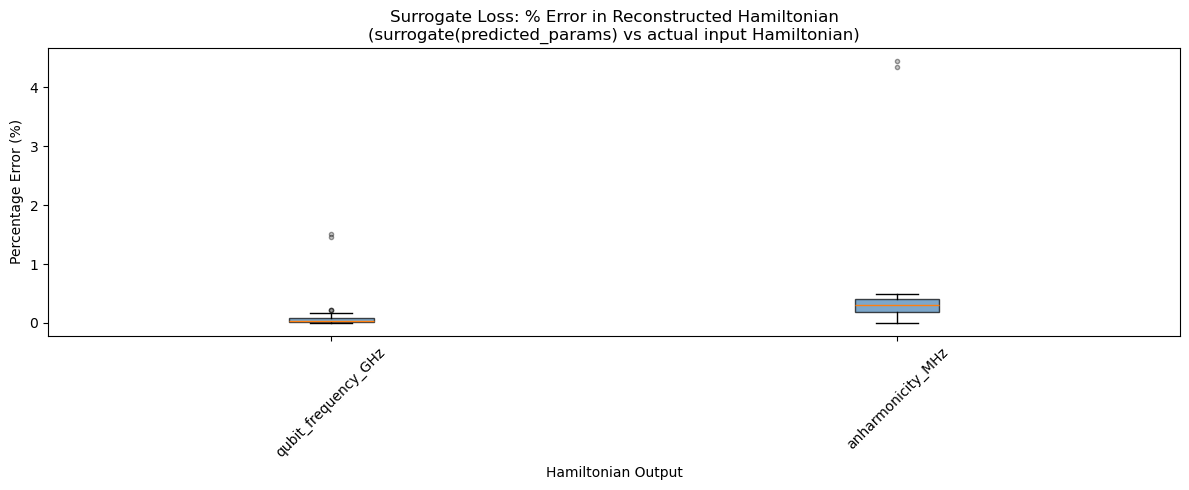

In [11]:
# box plot showing % error distribution per Hamiltonian output 
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data_per_col, labels=short_names, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor='grey'))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_ylabel('Percentage Error (%)')
ax.set_xlabel('Hamiltonian Output')
ax.set_title('Surrogate Loss: % Error in Reconstructed Hamiltonian\n(surrogate(predicted_params) vs actual input Hamiltonian)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_Hamiltonian_recon_pct_error_boxplot.pdf')
plt.show()

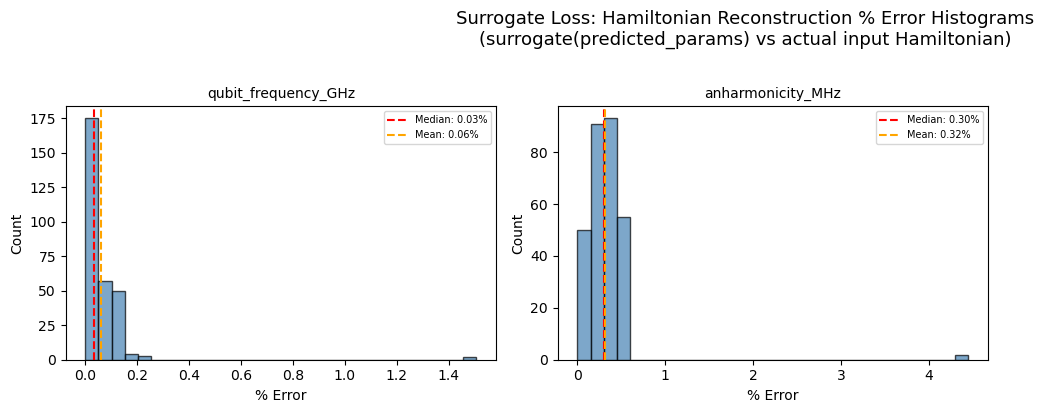

In [12]:
# histogram it too
n_cols_grid = 3
n_rows_grid = math.ceil(n_Hamiltonian_params / n_cols_grid)

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows_grid))
axes = axes.ravel()

for j in range(n_Hamiltonian_params):
    col_pct = pct_errors_unscaled[:, j]
    ax = axes[j]
    ax.hist(col_pct, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(np.median(col_pct), color='red', linestyle='--',
               label=f'Median: {np.median(col_pct):.2f}%')
    ax.axvline(np.mean(col_pct), color='orange', linestyle='--',
               label=f'Mean: {np.mean(col_pct):.2f}%')
    ax.set_title(short_names[j], fontsize=10)
    ax.set_xlabel('% Error')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

for k in range(n_Hamiltonian_params, len(axes)):
    fig.delaxes(axes[k])

fig.suptitle('Surrogate Loss: Hamiltonian Reconstruction % Error Histograms\n(surrogate(predicted_params) vs actual input Hamiltonian)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_Hamiltonian_recon_pct_error_histograms.pdf')
plt.show()

In [13]:
#look at the stats nicely
print('Hamiltonian Reconstruction % Error: surrogate(predicted_params) vs actual input Hamiltonian')
print()
print(f"{'Output':<25s} {'Median %':>10s} {'Mean %':>10s} {'90th %':>10s} {'Max %':>10s}")
print('-' * 70)
for j in range(n_Hamiltonian_params):
    col_pct = pct_errors_unscaled[:, j]
    name = short_names[j]
    print(f"{name:<25s} {np.median(col_pct):10.2f} {np.mean(col_pct):10.2f} "
          f"{np.percentile(col_pct, 90):10.2f} {np.max(col_pct):10.2f}")
print('-' * 70)
print(f"{'All outputs':<25s} {np.median(all_pct):10.2f} {np.mean(all_pct):10.2f} "
      f"{np.percentile(all_pct, 90):10.2f} {np.max(all_pct):10.2f}")

Hamiltonian Reconstruction % Error: surrogate(predicted_params) vs actual input Hamiltonian

Output                      Median %     Mean %     90th %      Max %
----------------------------------------------------------------------
qubit_frequency_GHz             0.03       0.06       0.12       1.51
anharmonicity_MHz               0.30       0.32       0.48       4.45
----------------------------------------------------------------------
All outputs                     0.11       0.19       0.45       4.45


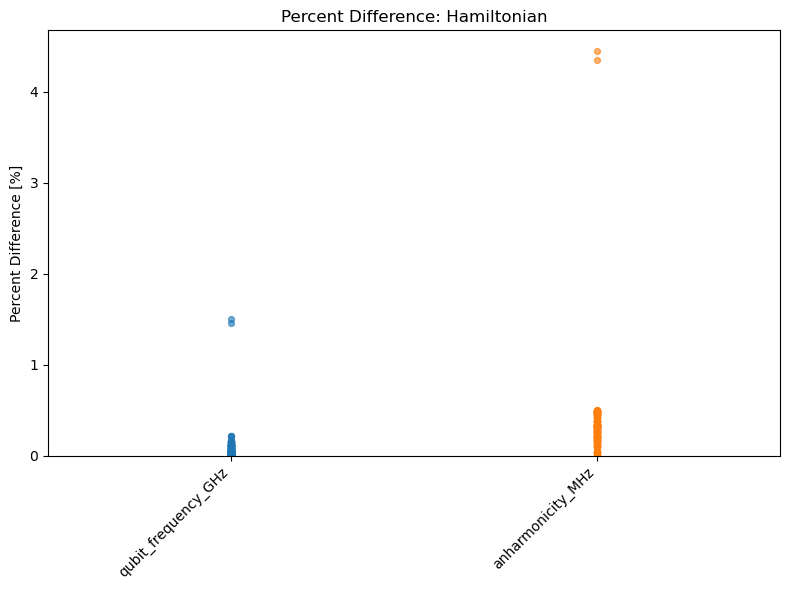

In [15]:
# scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
for j in range(n_Hamiltonian_params):
    col_pct = pct_errors_unscaled[:, j]
    ax.scatter(np.full(len(col_pct), j), col_pct, s=18, alpha=0.6)
ax.set_xticks(range(n_Hamiltonian_params))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel('Percent Difference [%]')
ax.set_title('Percent Difference: Hamiltonian')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, n_Hamiltonian_params - 0.5)
plt.tight_layout()
plt.savefig('plots/surrogate_loss_Hamiltonian_recon_pct_scatter.pdf')
plt.show()